# EDA — Three Airports On-Time Performance
IAD · DCA · BWI | 2015-01 through 2026-01

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

from src.eda import helpers
from config import PROCESSED_DATA_PATH

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
PROJECT_ROOT = Path('..').resolve()

df = pd.read_parquet(PROJECT_ROOT / PROCESSED_DATA_PATH / 'ontime_dmv.parquet')
print(df.shape)
df.dtypes

(2823044, 33)


Month                                int64
DayOfWeek                            int64
FlightDate                          object
Reporting_Airline                   object
Flight_Number_Reporting_Airline    float64
Origin                              object
OriginCityName                      object
OriginStateName                     object
Dest                                object
DestCityName                        object
DestState                           object
CRSDepTime                           int64
DepTime                            float64
DepDelay                           float64
DepDelayMinutes                    float64
TaxiOut                            float64
TaxiIn                             float64
CRSArrTime                           int64
ArrTime                            float64
ArrDelay                           float64
ArrDelayMinutes                    float64
Cancelled                          float64
CancellationCode                    object
Diverted   

## Section 1 — Basic Data Quality

In [3]:
# Fix dtypes
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Cancelled'] = df['Cancelled'].astype(bool)
df['Diverted'] = df['Diverted'].astype(bool)
df['Flight_Number_Reporting_Airline'] = df['Flight_Number_Reporting_Airline'].astype('Int64')
print("Dtypes fixed.")

Dtypes fixed.


In [4]:
# Null counts per column
df.isnull().sum().to_frame('null_count').assign(pct=lambda x: (x['null_count'] / len(df) * 100).round(2))

,null_count,pct
Month,0,0.00
DayOfWeek,0,0.00
FlightDate,0,0.00
Reporting_Airline,0,0.00
Flight_Number_Reporting_Airline,0,0.00
Origin,0,0.00
OriginCityName,0,0.00
OriginStateName,0,0.00
Dest,0,0.00
DestCityName,0,0.00


In [5]:
# Are delay cause nulls only on non-delayed flights?
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
delayed = df[df['ArrDelayMinutes'] > 0]
not_delayed = df[df['ArrDelayMinutes'] == 0]

print(f"Delayed flights:     {len(delayed):,}")
print(f"Non-delayed flights: {len(not_delayed):,}")
print(f"\nNull rate in delay cols for DELAYED flights:")
print(delayed[delay_cols].isnull().mean().round(3))
print(f"\nNull rate in delay cols for NON-DELAYED flights:")
print(not_delayed[delay_cols].isnull().mean().round(3))

Delayed flights:     960,254
Non-delayed flights: 1,787,750

Null rate in delay cols for DELAYED flights:
CarrierDelay        0.43
WeatherDelay        0.43
NASDelay            0.43
SecurityDelay       0.43
LateAircraftDelay   0.43
dtype: float64

Null rate in delay cols for NON-DELAYED flights:
CarrierDelay        1.00
WeatherDelay        1.00
NASDelay            1.00
SecurityDelay       1.00
LateAircraftDelay   1.00
dtype: float64


In [6]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

# Date range and monthly coverage
print(f"\nDate range: {df['FlightDate'].min().date()} to {df['FlightDate'].max().date()}")
monthly = df.groupby([df['FlightDate'].dt.year.rename('Year'), df['FlightDate'].dt.month.rename('Month')]).size()
missing = [(y, m) for y in range(2015, 2027) for m in range(1, 13)
           if not (y == 2026 and m > 1) and (y, m) not in monthly.index]
print(f"Missing year-month combos: {missing if missing else 'None'}")

Duplicate rows: 0

Date range: 2015-01-01 to 2026-01-31
Missing year-month combos: None


## Section 2 — Airport Row Counts

In [7]:
df['Origin'].value_counts().to_frame('flights').assign(pct=lambda x: (x['flights'] / len(df) * 100).round(1))

,flights,pct
Origin,,
DCA,1229075,43.50
BWI,1034176,36.60
IAD,559793,19.80


## Section 3 — Flight Volume

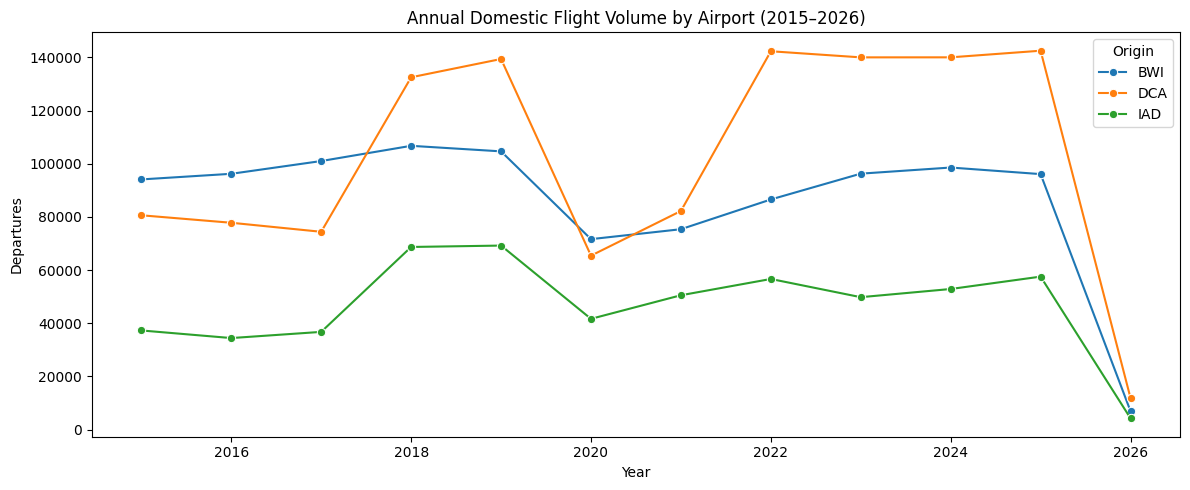

Origin,BWI,DCA,IAD
Year,,,
2015,94101,80613,37301
2016,96218,77802,34440
2017,101015,74408,36765
2018,106739,132516,68699
2019,104652,139388,69223
2020,71641,65432,41668
2021,75374,82229,50538
2022,86559,142302,56659
2023,96271,140005,49815


In [26]:
# Flights per airport per year
vol = (df.groupby(['Origin', df['FlightDate'].dt.year.rename('Year')])
         .size()
         .reset_index(name='flights'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=vol, x='Year', y='flights', hue='Origin', marker='o', ax=ax)
ax.set_title('Annual Domestic Flight Volume by Airport (2015–2026)')
ax.set_ylabel('Departures')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

vol.pivot(index='Year', columns='Origin', values='flights')

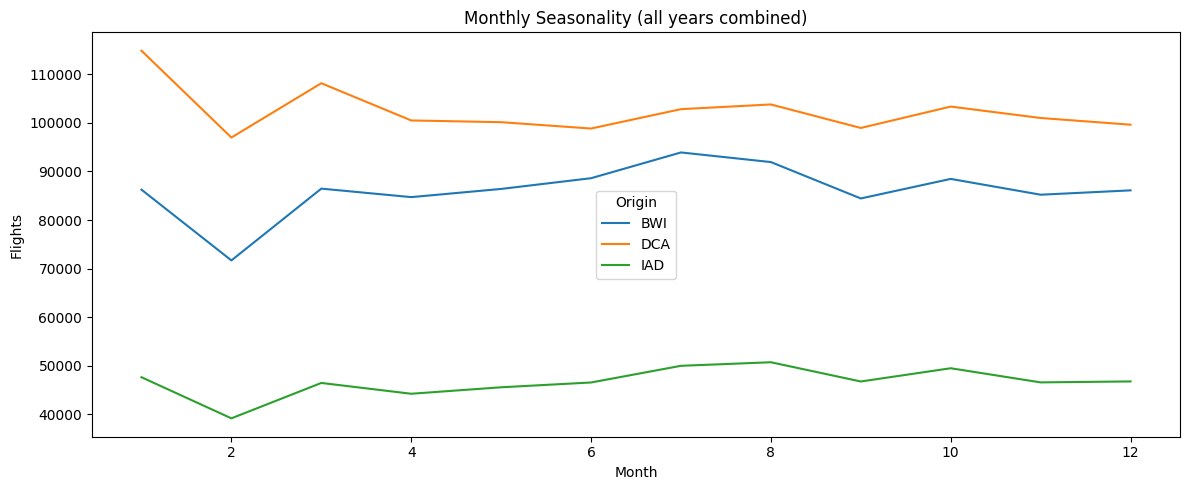

In [9]:
# Monthly seasonality
seas = df.groupby(['Origin', 'Month']).size().unstack('Origin')
seas.plot(figsize=(12, 5), title='Monthly Seasonality (all years combined)')
plt.xlabel('Month')
plt.ylabel('Flights')
plt.tight_layout()
plt.show()

## Section 4 — Airline Coverage

In [10]:
# Market share by carrier per airport
from src.eda.helpers import AIRLINE_NAMES

carrier_share = (df.groupby(['Origin', 'Reporting_Airline'])
                   .size()
                   .rename('flights')
                   .reset_index())
carrier_share['Airline'] = carrier_share['Reporting_Airline'].map(AIRLINE_NAMES).fillna(carrier_share['Reporting_Airline'])
carrier_share['share_pct'] = carrier_share.groupby('Origin')['flights'].transform(lambda x: x / x.sum() * 100).round(1)
carrier_share.sort_values(['Origin', 'flights'], ascending=[True, False])[['Origin', 'Reporting_Airline', 'Airline', 'flights', 'share_pct']]

,Origin,Reporting_Airline,Airline,flights,share_pct
15,BWI,WN,Southwest Airlines,750734,72.60
9,BWI,NK,Spirit Airlines,68377,6.60
4,BWI,DL,Delta Air Lines,64740,6.30
1,BWI,AA,American Airlines,49408,4.80
12,BWI,UA,United Airlines,33924,3.30
3,BWI,B6,JetBlue Airways,14360,1.40
6,BWI,F9,Frontier Airlines,11812,1.10
0,BWI,9E,Endeavor Air (Delta Connection),9371,0.90
2,BWI,AS,Alaska Airlines,8221,0.80
8,BWI,MQ,Envoy Air (American Eagle),6706,0.60


In [11]:
# Carrier presence check — WN at BWI, UA at IAD, AA at DCA
for airport, carrier in [('BWI', 'WN'), ('IAD', 'UA'), ('DCA', 'AA')]:
    flights = len(df[(df['Origin'] == airport) & (df['Reporting_Airline'] == carrier)])
    share = flights / len(df[df['Origin'] == airport]) * 100
    print(f"{carrier} @ {airport}: {flights:,} flights ({share:.1f}%)")

WN @ BWI: 750,734 flights (72.6%)
UA @ IAD: 283,723 flights (50.7%)
AA @ DCA: 270,633 flights (22.0%)


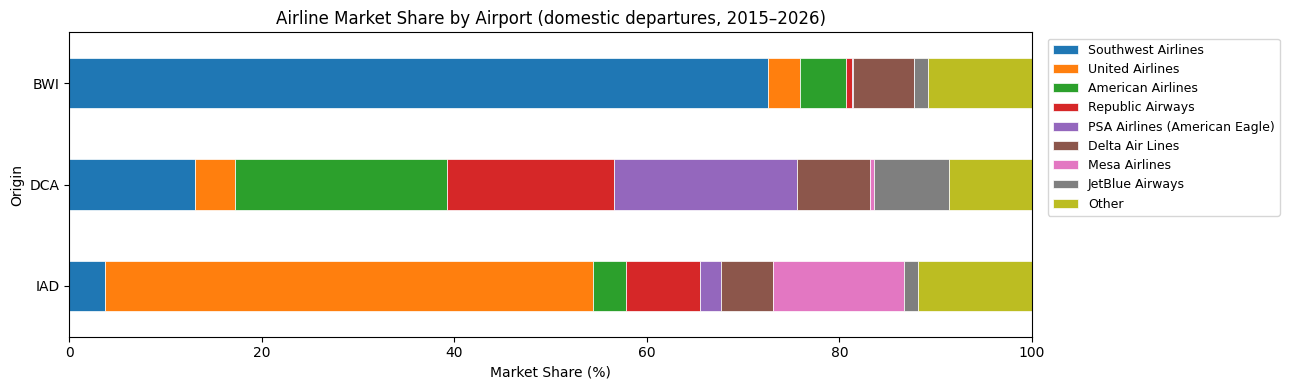

In [12]:
# Horizontal stacked bar — airline market share per airport
TOP_N = 8

carrier_pivot = (carrier_share
    .pivot(index='Origin', columns='Airline', values='share_pct')
    .fillna(0))

top_carriers = carrier_pivot.sum().nlargest(TOP_N).index.tolist()
plot_data = carrier_pivot[top_carriers].copy()
plot_data['Other'] = carrier_pivot.drop(columns=top_carriers).sum(axis=1)
plot_data = plot_data.loc[['IAD', 'DCA', 'BWI']]  # consistent order

colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(13, 4))
plot_data.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Market Share (%)')
ax.set_title('Airline Market Share by Airport (domestic departures, 2015–2026)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## Section 5 — Route Coverage

In [13]:
# Unique destination count per airport
print("Unique destinations per airport:")
print(df.groupby('Origin')['Dest'].nunique())

# Top 20 destinations per airport
print("\nTop 20 destinations:")
df.groupby(['Origin', 'Dest']).size().rename('flights').reset_index() \
  .sort_values(['Origin', 'flights'], ascending=[True, False]) \
  .groupby('Origin').head(20)

Unique destinations per airport:
Origin
BWI     84
DCA    107
IAD    109
Name: Dest, dtype: int64

Top 20 destinations:


,Origin,Dest,flights
2,BWI,ATL,65264
40,BWI,MCO,50039
8,BWI,BOS,47560
23,BWI,FLL,45488
12,BWI,CLT,36347
80,BWI,TPA,31175
52,BWI,ORD,29509
18,BWI,DEN,29067
20,BWI,DTW,27121
61,BWI,PVD,23042


**Note:** This dataset covers **domestic US operations only** (BTS on-time reporting). International routes — including IAD's transatlantic and transpacific flights — are entirely absent. IAD's international profile requires the BTS T-100 International Segment dataset.

In [14]:
# Destinations served by all three airports
dests_by_airport = df.groupby('Origin')['Dest'].apply(set)
shared_all_three = dests_by_airport['IAD'] & dests_by_airport['DCA'] & dests_by_airport['BWI']
shared_any_two = (dests_by_airport['IAD'] & dests_by_airport['DCA']) | \
                 (dests_by_airport['IAD'] & dests_by_airport['BWI']) | \
                 (dests_by_airport['DCA'] & dests_by_airport['BWI'])
print(f"Destinations served by all 3 airports: {len(shared_all_three)}")
print(f"Destinations served by at least 2 airports: {len(shared_any_two)}")
print(f"\nAll-three destinations: {sorted(shared_all_three)}")

Destinations served by all 3 airports: 66
Destinations served by at least 2 airports: 92

All-three destinations: ['ALB', 'ATL', 'AUS', 'AVL', 'BDL', 'BNA', 'BOS', 'BUF', 'CHS', 'CLE', 'CLT', 'CMH', 'CVG', 'DAY', 'DEN', 'DFW', 'DTW', 'EWR', 'FLL', 'GRR', 'GSP', 'IAH', 'IND', 'JAX', 'JFK', 'LAS', 'LAX', 'LGA', 'MCI', 'MCO', 'MDW', 'MEM', 'MHT', 'MIA', 'MKE', 'MSP', 'MSY', 'MYR', 'OKC', 'ORD', 'ORF', 'PBI', 'PDX', 'PHL', 'PHX', 'PIT', 'PVD', 'PWM', 'RDU', 'ROC', 'RSW', 'SAN', 'SAT', 'SAV', 'SDF', 'SEA', 'SFO', 'SJU', 'SLC', 'SRQ', 'STL', 'SYR', 'TPA', 'TUL', 'TYS', 'VPS']


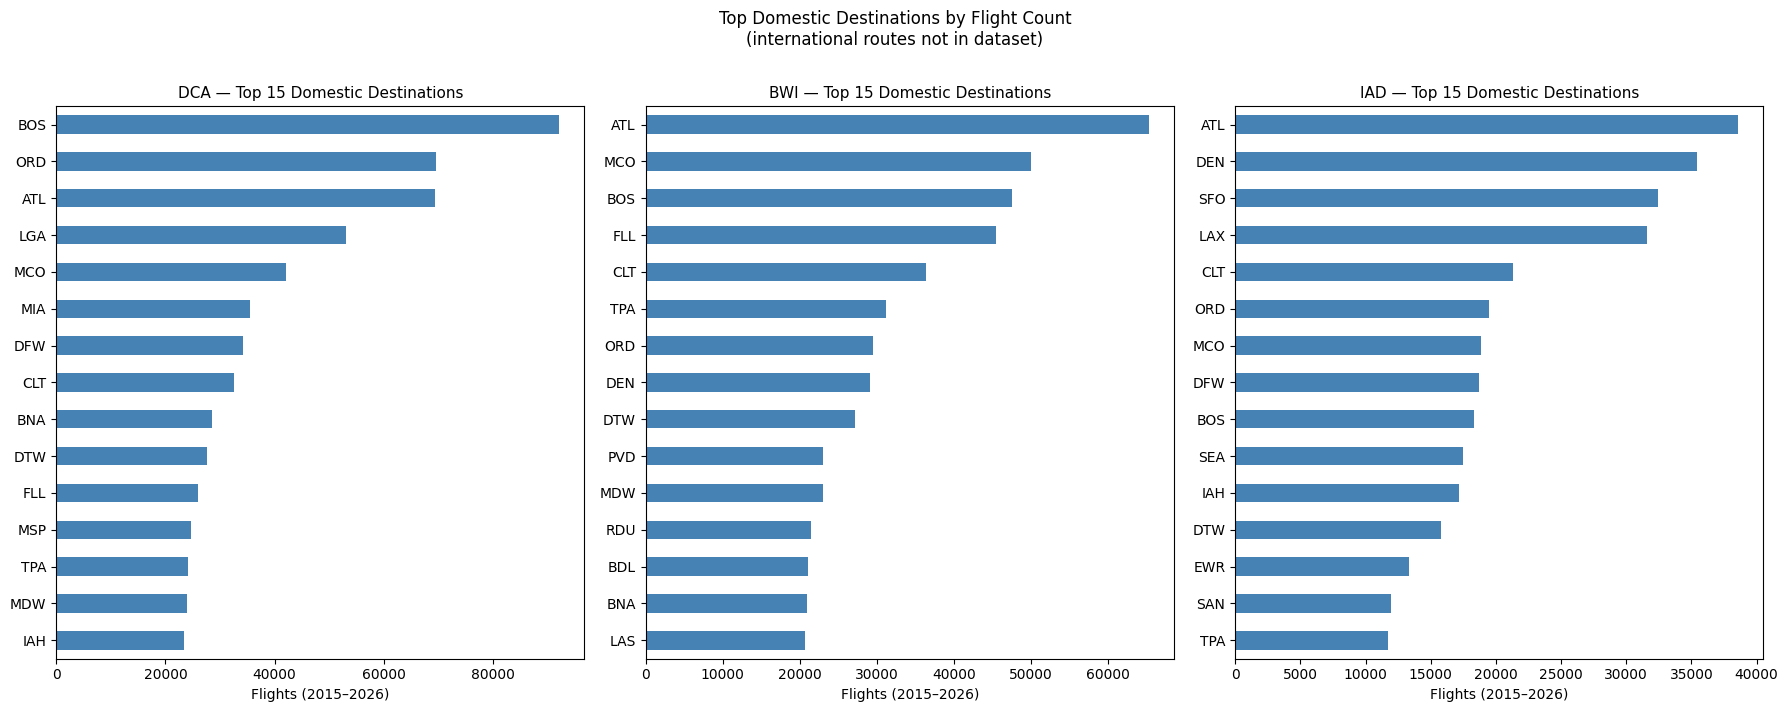

In [15]:
# Top 15 domestic destinations per airport — faceted horizontal bar
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, airport in zip(axes, ['DCA', 'BWI', 'IAD']):
    top_dests = (df[df['Origin'] == airport]
                 .groupby('Dest').size()
                 .nlargest(15)
                 .sort_values(ascending=True))
    top_dests.plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(f'{airport} — Top 15 Domestic Destinations', fontsize=11)
    ax.set_xlabel('Flights (2015–2026)')
    ax.set_ylabel('')

plt.suptitle('Top Domestic Destinations by Flight Count\n(international routes not in dataset)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Section 6 — Delay Profile

In [16]:
# On-time rate and avg delay per airport (exclude cancelled)
active = df[df['Cancelled'] == False]
delay_summary = active.groupby('Origin').agg(
    flights=('ArrDelay', 'count'),
    ontime_rate=('ArrDelayMinutes', lambda x: (x == 0).mean() * 100),
    mean_arr_delay=('ArrDelay', 'mean'),
    median_arr_delay=('ArrDelay', 'median'),
).round(2)
delay_summary

,flights,ontime_rate,mean_arr_delay,median_arr_delay
Origin,,,,
BWI,1008804,61.92,5.19,-5.00
DCA,1190817,66.05,4.92,-8.00
IAD,548383,67.95,3.98,-8.00


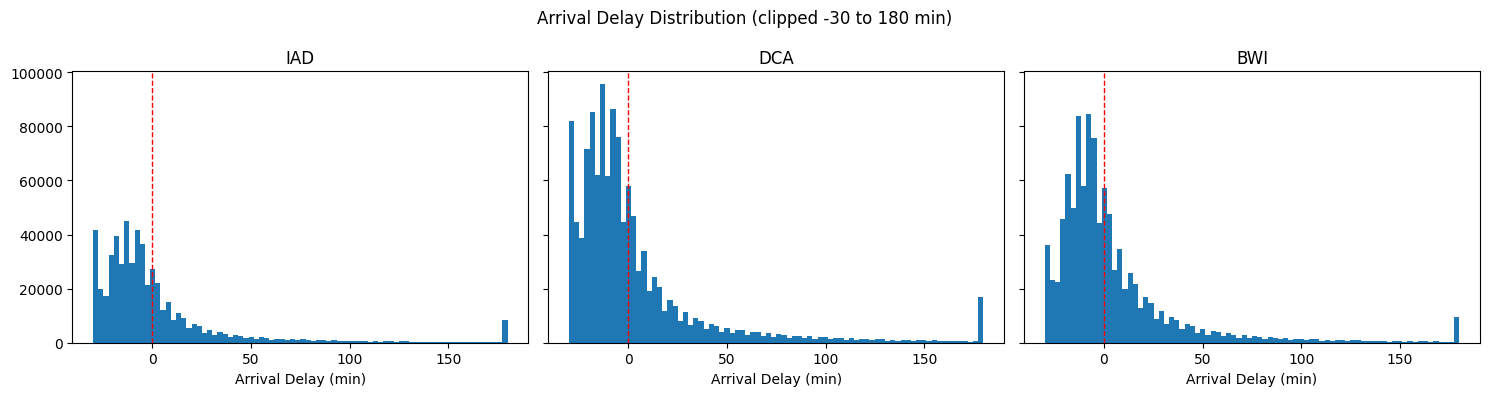

In [17]:
# ArrDelay distribution per airport
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, airport in zip(axes, ['IAD', 'DCA', 'BWI']):
    data = active[active['Origin'] == airport]['ArrDelay'].clip(-30, 180)
    ax.hist(data, bins=80, edgecolor='none')
    ax.set_title(airport)
    ax.set_xlabel('Arrival Delay (min)')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
plt.suptitle('Arrival Delay Distribution (clipped -30 to 180 min)')
plt.tight_layout()
plt.show()

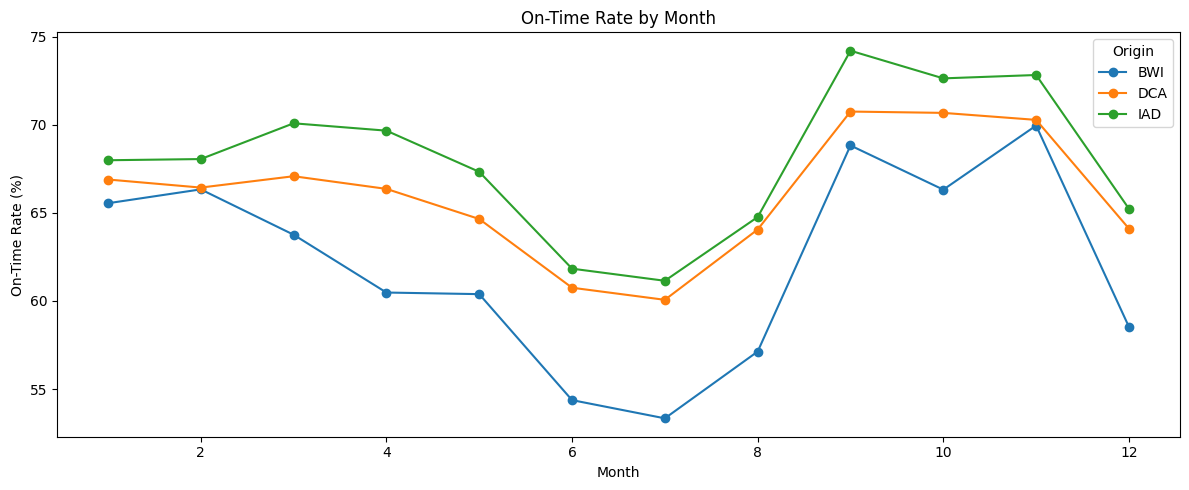

In [18]:
# On-time rate by month per airport
ontime_month = active.groupby(['Origin', 'Month'])['ArrDelayMinutes'].apply(lambda x: (x == 0).mean() * 100).unstack('Origin')
ontime_month.plot(figsize=(12, 5), marker='o', title='On-Time Rate by Month')
plt.ylabel('On-Time Rate (%)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

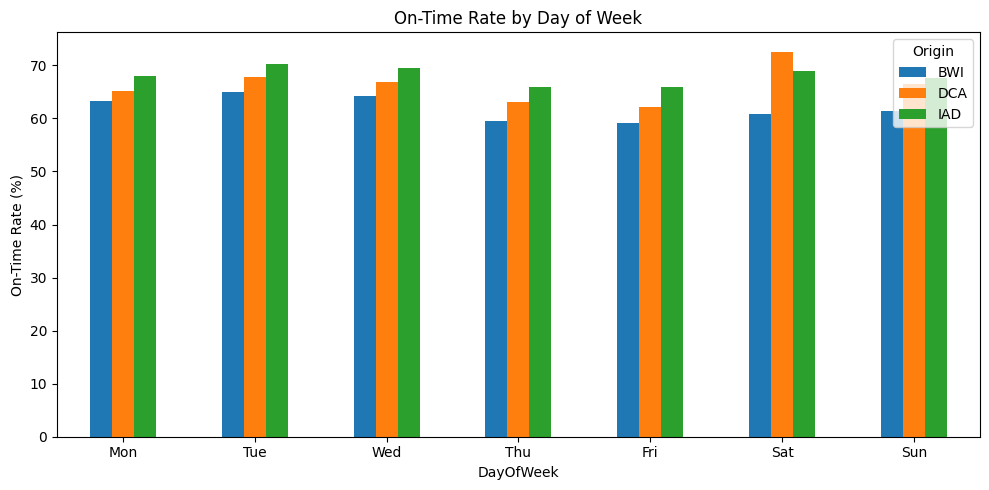

In [19]:
# On-time rate by day of week per airport
day_labels = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
ontime_dow = active.groupby(['Origin', 'DayOfWeek'])['ArrDelayMinutes'].apply(lambda x: (x == 0).mean() * 100).unstack('Origin')
ontime_dow.index = ontime_dow.index.map(day_labels)
ontime_dow.plot(kind='bar', figsize=(10, 5), title='On-Time Rate by Day of Week')
plt.ylabel('On-Time Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 7 — Delay Cause Breakdown

Delay cause breakdown (% of total delay minutes attributed):
LateAircraftDelay   40.10
CarrierDelay        32.10
NASDelay            22.00
WeatherDelay         5.60
SecurityDelay        0.20
dtype: float64


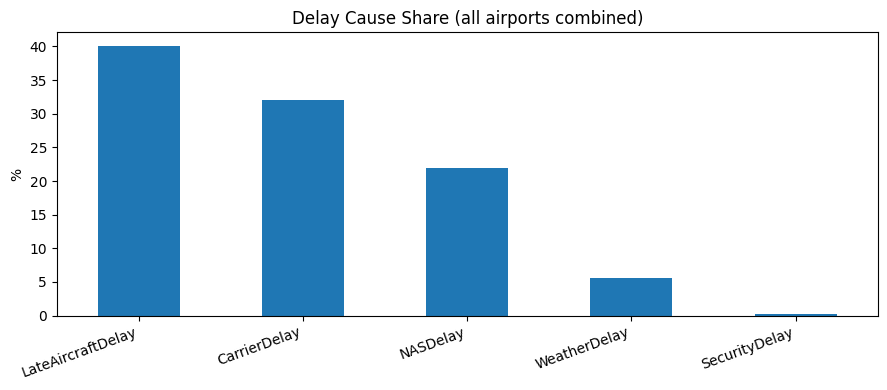

In [20]:
# Delay cause share among delayed flights
delayed_only = active[active['ArrDelayMinutes'] > 0].copy()
cause_totals = delayed_only[delay_cols].sum()
cause_pct = (cause_totals / cause_totals.sum() * 100).round(1).sort_values(ascending=False)
print("Delay cause breakdown (% of total delay minutes attributed):")
print(cause_pct)

cause_pct.plot(kind='bar', figsize=(9, 4), title='Delay Cause Share (all airports combined)')
plt.ylabel('%')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Section 8 — Cancellations and Diversions

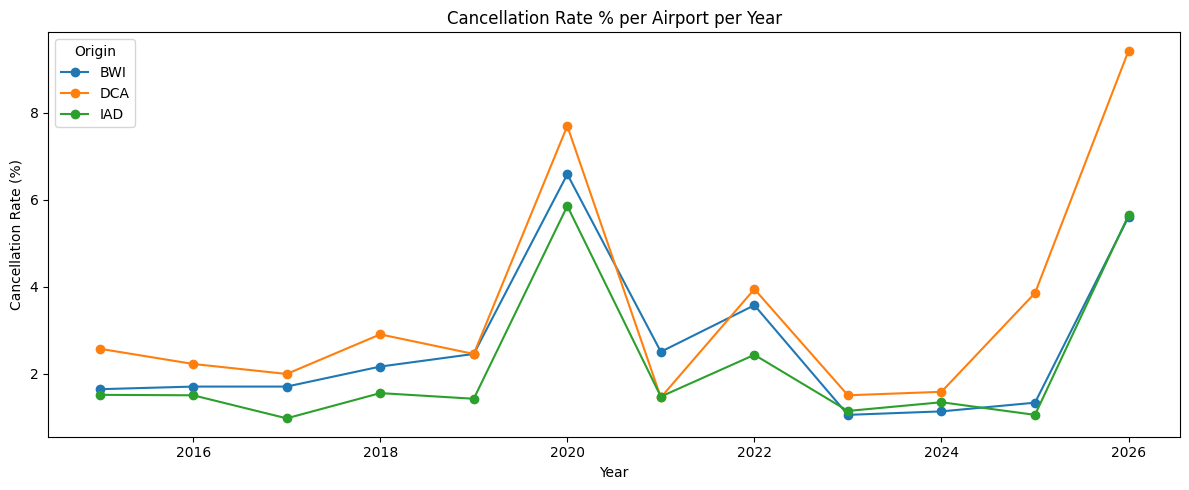

In [21]:
# Cancellation rate per airport per year
canc = df.groupby(['Origin', df['FlightDate'].dt.year.rename('Year')]).agg(
    total=('Cancelled', 'count'),
    cancelled=('Cancelled', 'sum')
)
canc['rate_pct'] = (canc['cancelled'] / canc['total'] * 100).round(2)
canc['rate_pct'].unstack('Origin').plot(figsize=(12, 5), marker='o', title='Cancellation Rate % per Airport per Year')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

In [22]:
# Cancellation code breakdown
print("Cancellation code breakdown (A=carrier, B=weather, C=NAS, D=security):")
print(df[df['Cancelled']]['CancellationCode'].value_counts())

print(f"\nDiversion rate per airport:")
print((df.groupby('Origin')['Diverted'].mean() * 100).round(3).to_frame('diversion_rate_%'))

Cancellation code breakdown (A=carrier, B=weather, C=NAS, D=security):
CancellationCode
B    33805
A    15137
D    10742
C     9305
Name: count, dtype: int64

Diversion rate per airport:
        diversion_rate_%
Origin                  
BWI                 0.20
DCA                 0.23
IAD                 0.21


## Section 9 — Taxi Times

Average taxi times (minutes):
        TaxiOut  TaxiIn
Origin                 
BWI       14.07    6.74
DCA       19.90    7.77
IAD       19.15    7.97


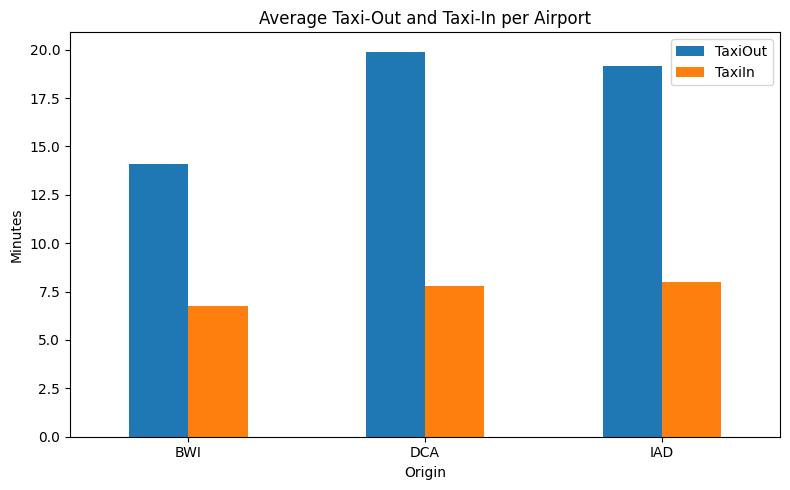

In [23]:
# Average taxi times per airport
taxi = active.groupby('Origin')[['TaxiOut', 'TaxiIn']].mean().round(2)
print("Average taxi times (minutes):")
print(taxi)

taxi.plot(kind='bar', figsize=(8, 5), title='Average Taxi-Out and Taxi-In per Airport')
plt.ylabel('Minutes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

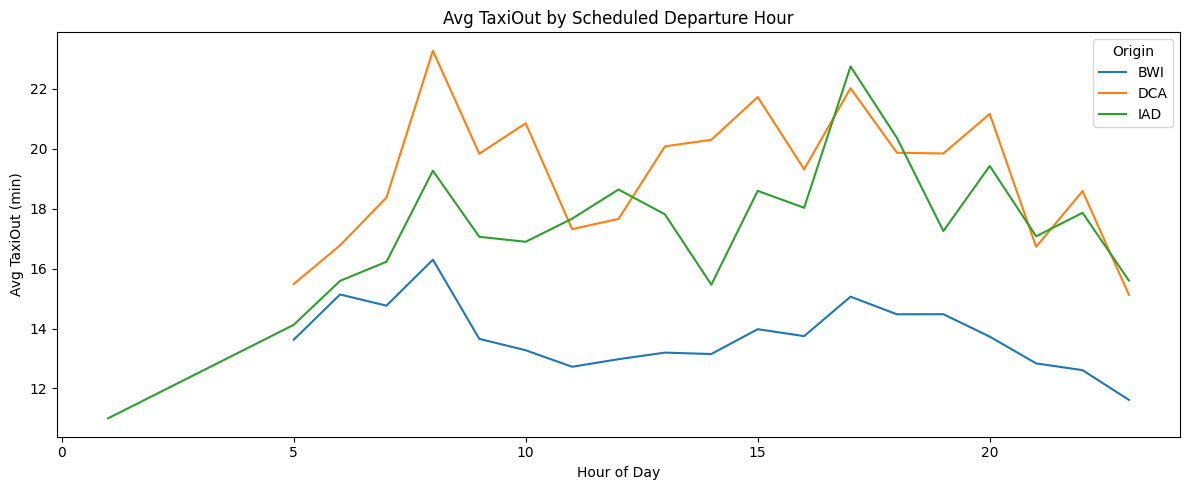

In [24]:
# TaxiOut by hour of day (does time of day matter?)
active_copy = active.copy()
active_copy['DepHour'] = (active_copy['CRSDepTime'] // 100).astype(int)
taxi_hour = active_copy.groupby(['Origin', 'DepHour'])['TaxiOut'].mean().unstack('Origin')
taxi_hour.plot(figsize=(12, 5), title='Avg TaxiOut by Scheduled Departure Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg TaxiOut (min)')
plt.tight_layout()
plt.show()

## Section 11 — Shared Destination Candidates (Part 4)

In [25]:
# Shared destinations with enough volume (min 500 flights/airport/year)
route_vol = df.groupby(['Origin', 'Dest', df['FlightDate'].dt.year.rename('Year')]).size().reset_index(name='flights')
avg_annual = route_vol.groupby(['Origin', 'Dest'])['flights'].mean().reset_index(name='avg_annual_flights')

# Keep routes with >= 500 avg annual flights per airport
high_vol = avg_annual[avg_annual['avg_annual_flights'] >= 500]
high_vol_dests = set(high_vol[high_vol['Origin'] == 'IAD']['Dest']) & \
                 set(high_vol[high_vol['Origin'] == 'DCA']['Dest']) & \
                 set(high_vol[high_vol['Origin'] == 'BWI']['Dest'])

print(f"Destinations served by all 3 airports with >= 500 avg annual flights each: {len(high_vol_dests)}")
print(sorted(high_vol_dests))

# Volume table for those destinations
avg_annual[avg_annual['Dest'].isin(high_vol_dests)].pivot(index='Dest', columns='Origin', values='avg_annual_flights').round(0).sort_values('IAD', ascending=False)

Destinations served by all 3 airports with >= 500 avg annual flights each: 28
['ATL', 'BDL', 'BNA', 'BOS', 'CHS', 'CLE', 'CLT', 'CMH', 'DEN', 'DFW', 'DTW', 'FLL', 'IAH', 'IND', 'JFK', 'LAX', 'MCO', 'MDW', 'MIA', 'MSP', 'MSY', 'ORD', 'ORF', 'PHX', 'PIT', 'RDU', 'SEA', 'TPA']


Origin,BWI,DCA,IAD
Dest,,,
ATL,5439.00,5778.00,3216.00
DEN,2422.00,1284.00,2953.00
LAX,1488.00,1239.00,2632.00
CLT,3029.00,2709.00,1775.00
ORD,2459.00,5798.00,1624.00
MCO,4170.00,3504.00,1573.00
DFW,1413.00,2852.00,1557.00
BOS,3963.00,7679.00,1529.00
SEA,612.00,679.00,1454.00
